✓  1257 trading days loaded.

  PORTFOLIO RISK SUMMARY  (Equal Weight)
  Stocks                       GOOGL, JPM, JNJ, V
  Period                       2020-01-01 → 2024-12-31
  Total Return                 +96.41%
  Annualised Return            +15.94%
  Annualised Volatility        21.86%
  Sharpe Ratio                 0.546
  Max Drawdown                 -33.62%

  INDIVIDUAL STOCK METRICS
  Ticker      Ann. Return  Ann. Volatility
  --------------------------------------
  GOOGL           +25.98%           32.51%
  JPM             +18.78%           32.54%
  JNJ              +4.34%           19.66%
  V               +14.64%           27.90%

📊  Chart saved → portfolio_risk_results.png


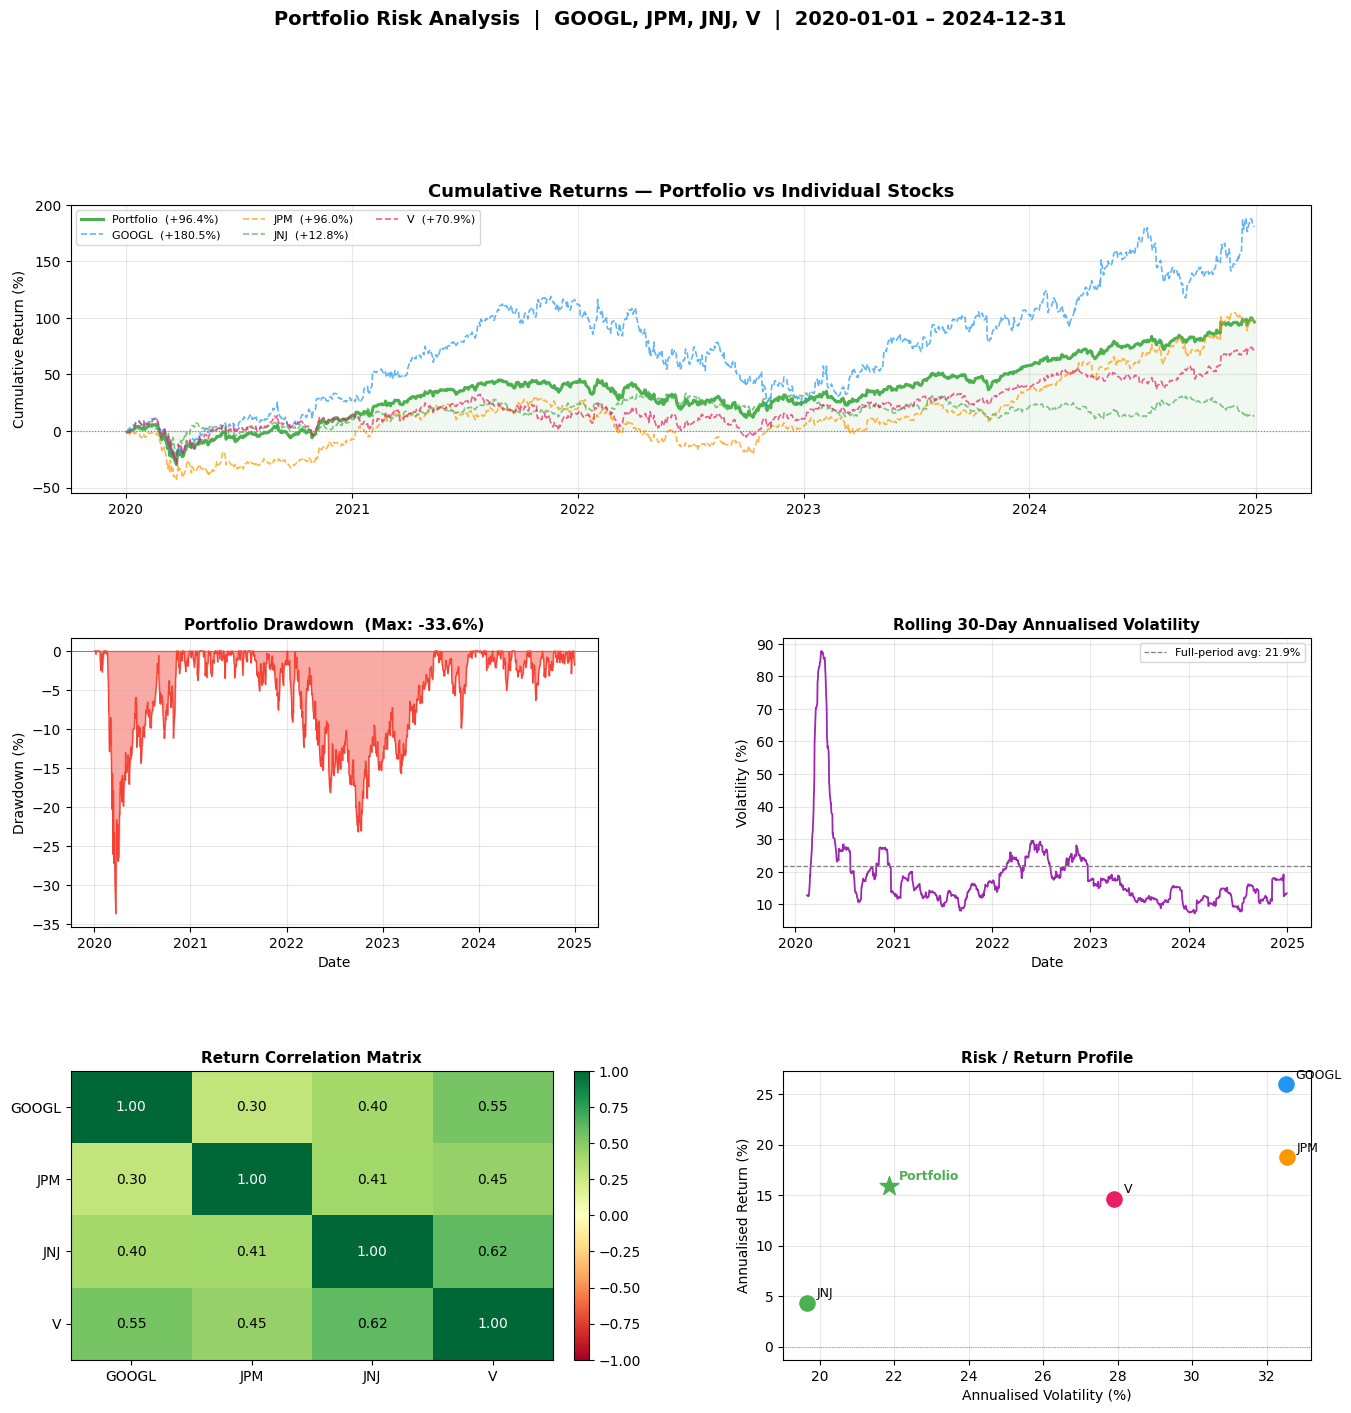

In [1]:
# ================================================================
#  Portfolio Risk Analysis
#  Stocks: GOOGL, JPM, JNJ, V  (S&P 500 — diversified across sectors)
#  Runnable in Google Colab or locally
# ================================================================

# ── 0. Install & imports ─────────────────────────────────────────

!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 1. Settings ──────────────────────────────────────────────────
TICKERS    = ["GOOGL", "JPM", "JNJ", "V"]   # Tech, Finance, Healthcare, Payments
START      = "2020-01-01"
END        = "2024-12-31"
RISK_FREE  = 0.04      # annual risk-free rate (approx. US T-bill)
CAPITAL    = 10_000    # hypothetical starting investment ($)

# Equal weighting — must sum to 1.0
WEIGHTS    = np.array([0.25, 0.25, 0.25, 0.25])

# ── 2. Download data ─────────────────────────────────────────────
print(f"Downloading data for: {', '.join(TICKERS)} …")
raw = yf.download(TICKERS, start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
raw.dropna(inplace=True)
print(f"✓  {len(raw)} trading days loaded.\n")

# ── 3. Daily returns ─────────────────────────────────────────────
returns = raw.pct_change().dropna()          # individual stock daily returns
port_returns = returns @ WEIGHTS             # weighted portfolio daily return

# ── 4. Cumulative returns ─────────────────────────────────────────
cum_port   = (1 + port_returns).cumprod()              # portfolio
cum_stocks = (1 + returns).cumprod()                   # each stock individually

# ── 5. Risk metrics ───────────────────────────────────────────────

# -- Volatility (annualised standard deviation)
daily_vol  = port_returns.std()
annual_vol = daily_vol * np.sqrt(252)

# -- Sharpe ratio (annualised)
annual_ret = port_returns.mean() * 252
sharpe     = (annual_ret - RISK_FREE) / annual_vol

# -- Maximum drawdown
roll_max   = cum_port.cummax()
drawdown   = (cum_port - roll_max) / roll_max
max_dd     = drawdown.min() * 100

# -- Total cumulative return
total_return = (cum_port.iloc[-1] - 1) * 100

# -- Correlation matrix
corr_matrix = returns.corr()

# -- Individual stock annualised metrics
stock_annual_ret = returns.mean() * 252 * 100
stock_annual_vol = returns.std()  * np.sqrt(252) * 100

# ── 6. Print summary ─────────────────────────────────────────────
print("=" * 45)
print("  PORTFOLIO RISK SUMMARY  (Equal Weight)")
print("=" * 45)
print(f"  {'Stocks':<28} {', '.join(TICKERS)}")
print(f"  {'Period':<28} {START} → {END}")
print(f"  {'Total Return':<28} {total_return:+.2f}%")
print(f"  {'Annualised Return':<28} {annual_ret*100:+.2f}%")
print(f"  {'Annualised Volatility':<28} {annual_vol*100:.2f}%")
print(f"  {'Sharpe Ratio':<28} {sharpe:.3f}")
print(f"  {'Max Drawdown':<28} {max_dd:.2f}%")
print("=" * 45)

print("\n  INDIVIDUAL STOCK METRICS")
print(f"  {'Ticker':<10} {'Ann. Return':>12} {'Ann. Volatility':>16}")
print("  " + "-" * 38)
for t in TICKERS:
    print(f"  {t:<10} {stock_annual_ret[t]:>+11.2f}%  {stock_annual_vol[t]:>14.2f}%")

# ── 7. Plot ───────────────────────────────────────────────────────
COLORS = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63",
          "#9C27B0", "#00BCD4", "#FF5722", "#8BC34A"]

fig = plt.figure(figsize=(16, 15))
gs  = gridspec.GridSpec(3, 2, hspace=0.50, wspace=0.35)

# ── Panel 1 (top, full width): Portfolio cumulative return ──────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(cum_port.index, (cum_port - 1) * 100,
         color="#4CAF50", lw=2.2, label=f"Portfolio  ({total_return:+.1f}%)")
ax1.fill_between(cum_port.index, (cum_port - 1) * 100, 0,
                 alpha=0.08, color="#4CAF50")
for i, t in enumerate(TICKERS):
    ax1.plot(cum_stocks.index, (cum_stocks[t] - 1) * 100,
             color=COLORS[i], lw=1.2, ls="--", alpha=0.7,
             label=f"{t}  ({(cum_stocks[t].iloc[-1]-1)*100:+.1f}%)")
ax1.axhline(0, color="grey", lw=0.8, ls=":")
ax1.set_title("Cumulative Returns — Portfolio vs Individual Stocks",
              fontsize=13, fontweight="bold")
ax1.set_ylabel("Cumulative Return (%)")
ax1.legend(fontsize=8, ncol=3)
ax1.grid(alpha=0.3)

# ── Panel 2 (mid-left): Drawdown ─────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.fill_between(drawdown.index, drawdown * 100, 0,
                 color="#F44336", alpha=0.45)
ax2.plot(drawdown.index, drawdown * 100, color="#F44336", lw=0.9)
ax2.axhline(0, color="grey", lw=0.7)
ax2.set_title(f"Portfolio Drawdown  (Max: {max_dd:.1f}%)",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Date")
ax2.grid(alpha=0.3)

# ── Panel 3 (mid-right): Rolling 30-day volatility ───────────────
ax3 = fig.add_subplot(gs[1, 1])
roll_vol = port_returns.rolling(30).std() * np.sqrt(252) * 100
ax3.plot(roll_vol.index, roll_vol, color="#9C27B0", lw=1.3)
ax3.axhline(annual_vol * 100, color="grey", ls="--", lw=0.9,
            label=f"Full-period avg: {annual_vol*100:.1f}%")
ax3.set_title("Rolling 30-Day Annualised Volatility",
              fontsize=11, fontweight="bold")
ax3.set_ylabel("Volatility (%)")
ax3.set_xlabel("Date")
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# ── Panel 4 (bottom-left): Correlation heatmap ───────────────────
ax4 = fig.add_subplot(gs[2, 0])
im = ax4.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax4.set_xticks(range(len(TICKERS))); ax4.set_xticklabels(TICKERS)
ax4.set_yticks(range(len(TICKERS))); ax4.set_yticklabels(TICKERS)
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax4.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=10,
                 color="black" if abs(corr_matrix.iloc[i, j]) < 0.7 else "white")
plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
ax4.set_title("Return Correlation Matrix", fontsize=11, fontweight="bold")

# ── Panel 5 (bottom-right): Risk/Return scatter ──────────────────
ax5 = fig.add_subplot(gs[2, 1])
for i, t in enumerate(TICKERS):
    ax5.scatter(stock_annual_vol[t], stock_annual_ret[t],
                color=COLORS[i], s=120, zorder=5)
    ax5.annotate(t, (stock_annual_vol[t], stock_annual_ret[t]),
                 textcoords="offset points", xytext=(7, 4), fontsize=9)

# Plot portfolio point
ax5.scatter(annual_vol * 100, annual_ret * 100,
            color="#4CAF50", s=200, marker="*", zorder=6, label="Portfolio")
ax5.annotate("Portfolio", (annual_vol * 100, annual_ret * 100),
             textcoords="offset points", xytext=(7, 4),
             fontsize=9, fontweight="bold", color="#4CAF50")

ax5.axhline(0, color="grey", lw=0.6, ls=":")
ax5.set_xlabel("Annualised Volatility (%)")
ax5.set_ylabel("Annualised Return (%)")
ax5.set_title("Risk / Return Profile", fontsize=11, fontweight="bold")
ax5.grid(alpha=0.3)

plt.suptitle(f"Portfolio Risk Analysis  |  {', '.join(TICKERS)}  |  {START} – {END}",
             fontsize=14, fontweight="bold", y=1.01)

plt.savefig("portfolio_risk_results.png", dpi=150, bbox_inches="tight")
print("\n📊  Chart saved → portfolio_risk_results.png")
plt.show()